**GABS Project**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Load connectomes
alzheimer = np.load('../Data/project1.npy')  # (46, 96, 96)
healthy = np.load('../Data/project2.npy')    # (42, 96, 96)

print(f"Alzheimer's: {alzheimer.shape[0]} subjects, {alzheimer.shape[1]}x{alzheimer.shape[2]} parcels")
print(f"Healthy Controls: {healthy.shape[0]} subjects, {healthy.shape[1]}x{healthy.shape[2]} parcels")

Alzheimer's: 46 subjects, 96x96 parcels
Healthy Controls: 42 subjects, 96x96 parcels


## 1. Mean Connectomes: Alzheimer's vs Healthy Controls

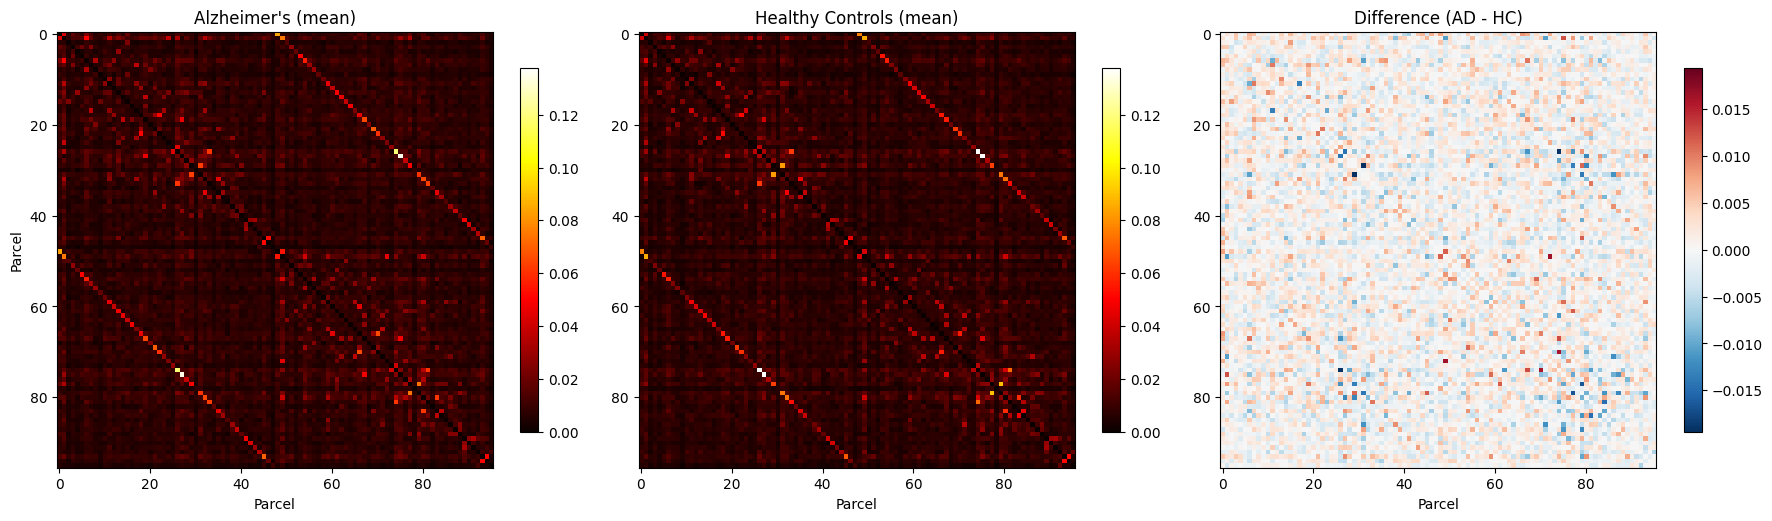

In [8]:
mean_alz = alzheimer.mean(axis=0)
mean_hc = healthy.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(mean_alz, cmap='hot', vmin=0, vmax=max(mean_alz.max(), mean_hc.max()))
axes[0].set_title("Alzheimer's (mean)")
axes[0].set_xlabel('Parcel')
axes[0].set_ylabel('Parcel')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(mean_hc, cmap='hot', vmin=0, vmax=max(mean_alz.max(), mean_hc.max()))
axes[1].set_title('Healthy Controls (mean)')
axes[1].set_xlabel('Parcel')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

diff = mean_alz - mean_hc
lim = np.abs(diff).max()
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[2].set_title('Difference (AD - HC)')
axes[2].set_xlabel('Parcel')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

## 2. Distribution of Connection Strengths

Each subject's connectome is a 96×96 matrix. Each entry is a number representing how strongly two brain regions are connected structurally (derived from diffusion imaging). A higher value means a stronger connection.

Here we take all ~4500 unique connection weights (upper triangle) across all subjects and plot how many are weak vs strong. The two groups (AD and HC) are overlaid so we can see if Alzheimer's brains have a different pattern — e.g., fewer strong connections. The log-scale plot on the right makes it easier to see rare strong connections.

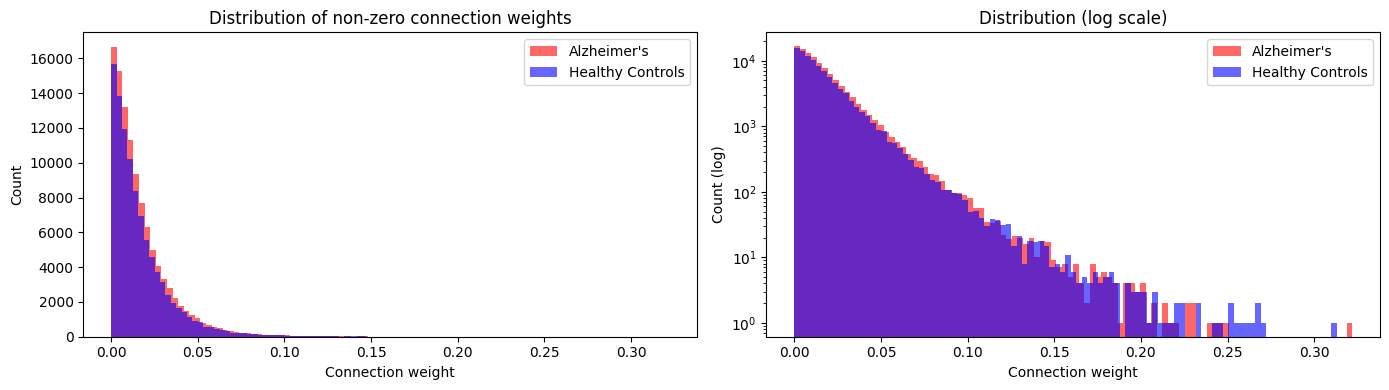

In [9]:
# Distribution of non-zero connection weights (upper triangle to avoid duplicates)
triu_idx = np.triu_indices(96, k=1)

alz_weights = alzheimer[:, triu_idx[0], triu_idx[1]].flatten()
hc_weights = healthy[:, triu_idx[0], triu_idx[1]].flatten()

# Filter out zeros for cleaner histogram
alz_nonzero = alz_weights[alz_weights > 0]
hc_nonzero = hc_weights[hc_weights > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(alz_nonzero, bins=100, alpha=0.6, label="Alzheimer's", color='red')
axes[0].hist(hc_nonzero, bins=100, alpha=0.6, label='Healthy Controls', color='blue')
axes[0].set_xlabel('Connection weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of non-zero connection weights')
axes[0].legend()

# Log scale for better visibility of tails
axes[1].hist(alz_nonzero, bins=100, alpha=0.6, label="Alzheimer's", color='red')
axes[1].hist(hc_nonzero, bins=100, alpha=0.6, label='Healthy Controls', color='blue')
axes[1].set_xlabel('Connection weight')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Node Strength (Degree) Comparison

Node strength is the sum of all connection weights for a single brain region (parcel). It tells us how well-connected that region is to the rest of the brain — a high value means that region has many strong connections.

We compute this for each of the 96 parcels, averaged across subjects. The left plot compares AD vs HC side by side. The right plot shows the difference: red bars mean AD has stronger connectivity at that parcel, blue means HC is stronger. This helps identify which specific brain regions are most affected in Alzheimer's.

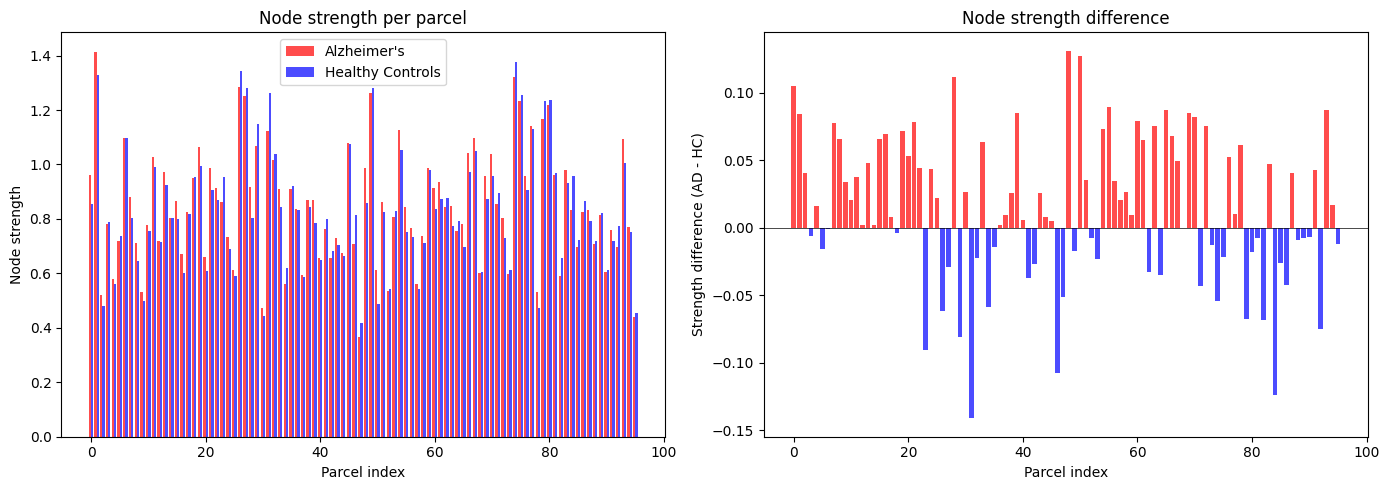

In [11]:
# Node strength = sum of connection weights per parcel
alz_strength = alzheimer.sum(axis=2).mean(axis=0)  # mean across subjects, per parcel
hc_strength = healthy.sum(axis=2).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of node strengths
x = np.arange(96)
axes[0].bar(x - 0.2, alz_strength, width=0.4, label="Alzheimer's", color='red', alpha=0.7)
axes[0].bar(x + 0.2, hc_strength, width=0.4, label='Healthy Controls', color='blue', alpha=0.7)
axes[0].set_xlabel('Parcel index')
axes[0].set_ylabel('Node strength')
axes[0].set_title('Node strength per parcel')
axes[0].legend()

# Difference in node strength
strength_diff = alz_strength - hc_strength
colors = ['red' if d > 0 else 'blue' for d in strength_diff]
axes[1].bar(x, strength_diff, color=colors, alpha=0.7)
axes[1].set_xlabel('Parcel index')
axes[1].set_ylabel('Strength difference (AD - HC)')
axes[1].set_title('Node strength difference')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Individual Subject Variability (Total Connection Strength per Subject)

Here we collapse each subject's entire 96×96 connectome into a single number by summing all weights. This is a rough measure of overall "how connected" that person's brain is.

The boxplot shows the distribution for each group (median, spread, outliers). The strip plot shows each subject as a dot. This lets us check two things: (1) whether AD subjects tend to have weaker total connectivity than HC, and (2) how much variation there is within each group.

/tmp/ipykernel_16178/2452401935.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([alz_total, hc_total], labels=["Alzheimer's", "Healthy Controls"])


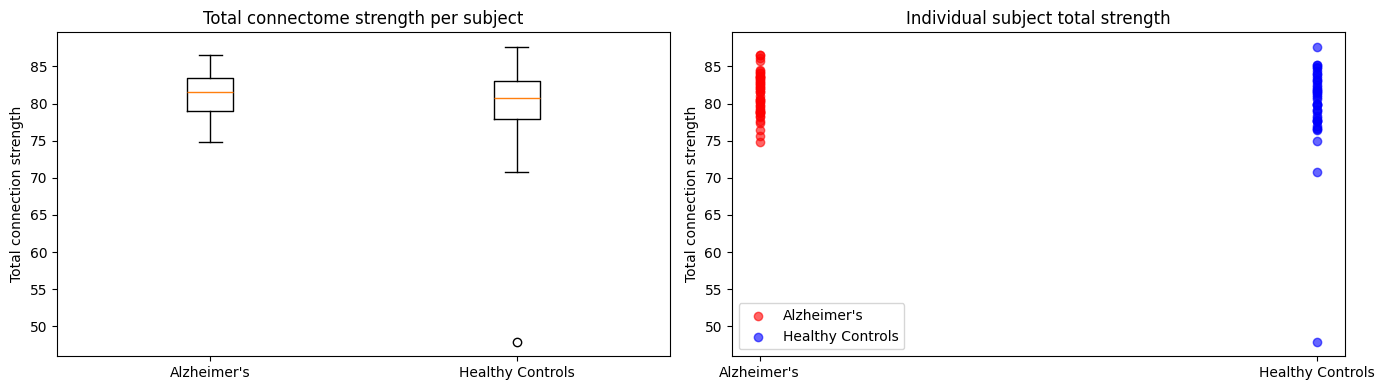

Alzheimer's: mean=81.30, std=2.83
Healthy Controls: mean=79.83, std=5.97


In [12]:
# Total connection strength per subject
alz_total = alzheimer.sum(axis=(1, 2))
hc_total = healthy.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot
axes[0].boxplot([alz_total, hc_total], labels=["Alzheimer's", "Healthy Controls"])
axes[0].set_ylabel('Total connection strength')
axes[0].set_title('Total connectome strength per subject')

# Scatter / strip plot
axes[1].scatter(np.zeros(len(alz_total)), alz_total, alpha=0.6, color='red', label="Alzheimer's")
axes[1].scatter(np.ones(len(hc_total)), hc_total, alpha=0.6, color='blue', label='Healthy Controls')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Alzheimer's", "Healthy Controls"])
axes[1].set_ylabel('Total connection strength')
axes[1].set_title('Individual subject total strength')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Alzheimer's: mean={alz_total.mean():.2f}, std={alz_total.std():.2f}")
print(f"Healthy Controls: mean={hc_total.mean():.2f}, std={hc_total.std():.2f}")

## 5. Example Single-Subject Connectomes

/tmp/ipykernel_16178/547883646.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


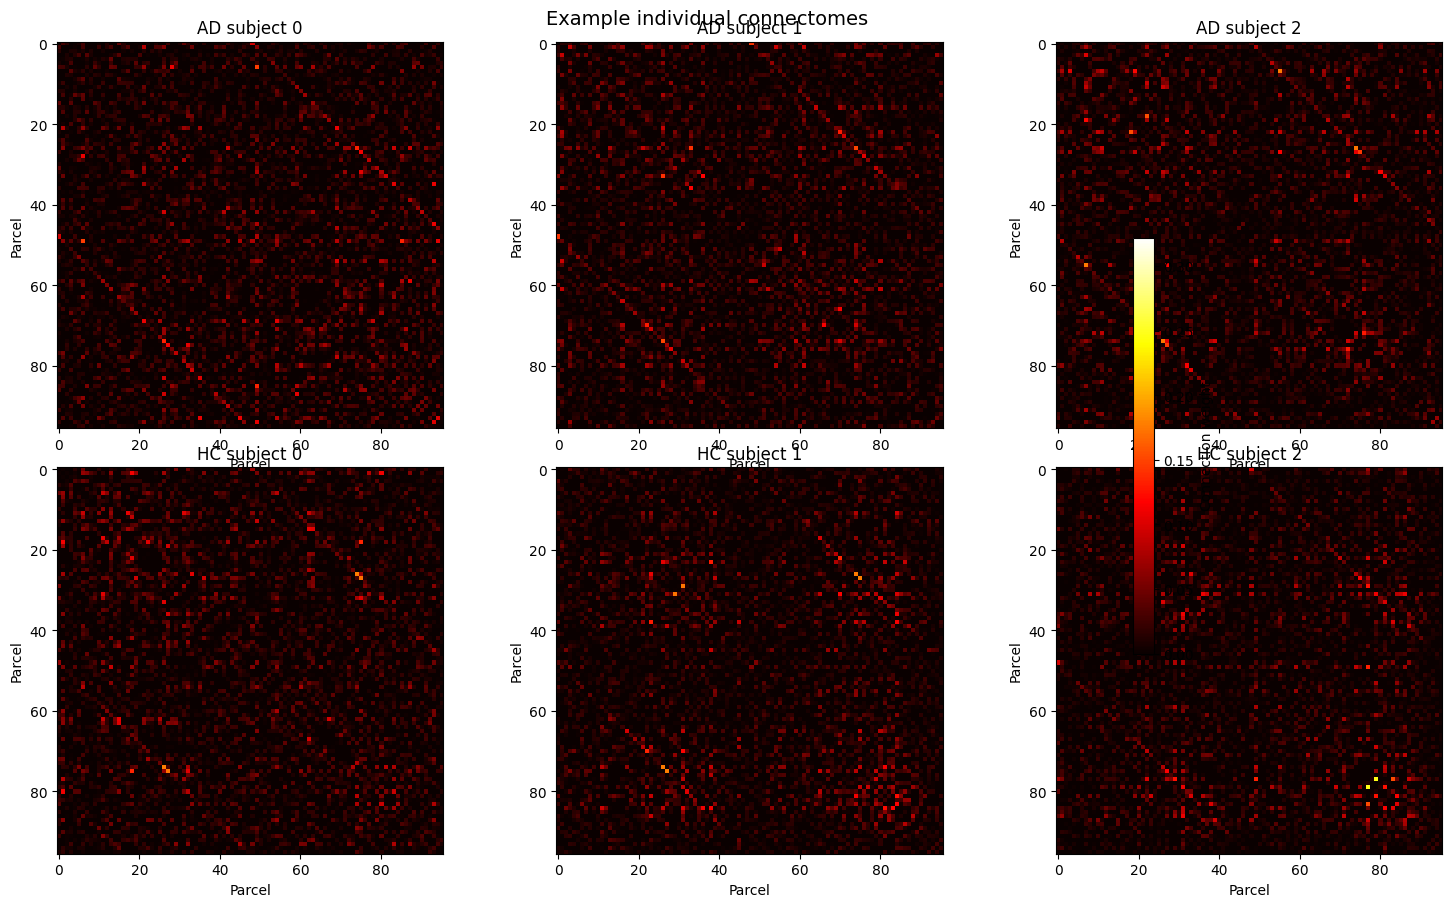

In [ ]:
# Show 3 example subjects from each group
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vmax = max(alzheimer.max(), healthy.max())

for i in range(3):
    im = axes[0, i].imshow(alzheimer[i], cmap='hot', vmin=0, vmax=vmax)
    axes[0, i].set_title(f'AD subject {i}')
    axes[0, i].set_xlabel('Parcel')
    axes[0, i].set_ylabel('Parcel')

    im = axes[1, i].imshow(healthy[i], cmap='hot', vmin=0, vmax=vmax)
    axes[1, i].set_title(f'HC subject {i}')
    axes[1, i].set_xlabel('Parcel')
    axes[1, i].set_ylabel('Parcel')

fig.colorbar(im, ax=axes, shrink=0.6, label='Connection weight')
plt.suptitle('Example individual connectomes', fontsize=14)
plt.tight_layout()
plt.show()